FEM 1D - Finite Element Method for a 1D Bar (Axial Loading)
=====================================================================
Problem: A bar of length L = 1.0 m, fixed at one end, subjected to an
         axial load of 10 kN at the free end.
         Material: Steel (E = 210 GPa), Cross-section A = 0.01 m²

All 7 Core Steps are implemented below.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [5]:
# STEP 1: PREPROCESSING — DISCRETIZATION OF THE CONTINUUM

L          = 1.0        # Total bar length (m)
n_elements = 5          # Number of elements
n_nodes    = n_elements + 1  # Number of nodes

nodes    = np.linspace(0, L, n_nodes)       # Node coordinates (m)
elements = [[i, i + 1] for i in range(n_elements)]  # Connectivity

print(f"  Bar length      : {L} m")
print(f"  Number of elements : {n_elements}")
print(f"  Number of nodes    : {n_nodes}")
print(f"  Node coordinates   : {nodes} m")
print(f"  Element connectivity:\n    {elements}\n")

  Bar length      : 1.0 m
  Number of elements : 5
  Number of nodes    : 6
  Node coordinates   : [0.  0.2 0.4 0.6 0.8 1. ] m
  Element connectivity:
    [[0, 1], [1, 2], [2, 3], [3, 4], [4, 5]]



In [6]:
# STEP 2: MATERIAL & PROPERTY DEFINITION

E  = 210e9          # Young's Modulus (Pa)
A  = 0.01           # Cross-sectional area (m²)
le = L / n_elements # Element length (m)

print(f"  Young's Modulus E = {E:.3e} Pa")
print(f"  Cross-section  A = {A} m²")
print(f"  Element length le = {le} m")
print(f"  Axial rigidity AE = {A * E:.3e} N\n")

  Young's Modulus E = 2.100e+11 Pa
  Cross-section  A = 0.01 m²
  Element length le = 0.2 m
  Axial rigidity AE = 2.100e+09 N



In [9]:
# STEP 3: ELEMENT STIFFNESS MATRIX (Local)
#
#  Formulation (direct stiffness / energy method):
#  For a 1D linear bar element with 2 nodes (u1, u2):
#
#         AE   [ 1  -1 ]
#  [k] = ---- * [      ]
#          Le  [-1   1 ]
#
#  Derived from: PE = 0.5 * integral(E * eps² * A dx)
#  where eps = (u2 - u1) / Le  (axial strain)

k_local = (A * E / le) * np.array([[1, -1],
                                    [-1,  1]])

print("  [k_local] = (AE/Le) × [[1, -1], [-1, 1]]")
print(f"\n  [k_local] =\n{k_local}\n")


  [k_local] = (AE/Le) × [[1, -1], [-1, 1]]

  [k_local] =
[[ 1.05e+10 -1.05e+10]
 [-1.05e+10  1.05e+10]]



In [10]:
# STEP 4: GLOBAL ASSEMBLY
#
#  Assemble all local [k_e] into [K_global] using the
#  direct stiffness method. Each element contributes to
#  its two DOF (node i and node j) via the scatter matrix.

K_global = np.zeros((n_nodes, n_nodes))

for el in elements:
    K_global[np.ix_(el, el)] += k_local

print("  Global Stiffness Matrix [K] (n_nodes × n_nodes):")
print(f"  Shape = {K_global.shape}")
np.set_printoptions(precision=2, suppress=True)
print(f"\n  [K_global] (N/m) =\n{K_global}\n")

  Global Stiffness Matrix [K] (n_nodes × n_nodes):
  Shape = (6, 6)

  [K_global] (N/m) =
[[ 1.05e+10 -1.05e+10  0.00e+00  0.00e+00  0.00e+00  0.00e+00]
 [-1.05e+10  2.10e+10 -1.05e+10  0.00e+00  0.00e+00  0.00e+00]
 [ 0.00e+00 -1.05e+10  2.10e+10 -1.05e+10  0.00e+00  0.00e+00]
 [ 0.00e+00  0.00e+00 -1.05e+10  2.10e+10 -1.05e+10  0.00e+00]
 [ 0.00e+00  0.00e+00  0.00e+00 -1.05e+10  2.10e+10 -1.05e+10]
 [ 0.00e+00  0.00e+00  0.00e+00  0.00e+00 -1.05e+10  1.05e+10]]



In [11]:
# STEP 5: BOUNDARY CONDITIONS & LOADS
#
#  Essential BC: u[0] = 0   (left end fixed)
#  Natural  BC: F[-1] = 10,000 N (right end free, loaded)
#
#  Method: Elimination — remove fixed DOF rows/columns.

F = np.zeros(n_nodes)
F[-1] = 10000.0      # 10 kN applied at free end (Node 5)

print(f"  Applied force vector F = {F} N")
print(f"  Boundary condition: u[0] = 0 (node 0 fixed)")

# Apply BC by elimination: remove DOF 0
K_reduced = K_global[1:, 1:]
F_reduced = F[1:]

print(f"\n  Reduced [K] shape = {K_reduced.shape}")
print(f"  Reduced {{F}} = {F_reduced} N\n")

  Applied force vector F = [    0.     0.     0.     0.     0. 10000.] N
  Boundary condition: u[0] = 0 (node 0 fixed)

  Reduced [K] shape = (5, 5)
  Reduced {F} = [    0.     0.     0.     0. 10000.] N



In [12]:
# STEP 6: SOLUTION OF GLOBAL EQUATION SYSTEM
#
#  Solve:  [K_reduced] {u_free} = {F_reduced}
#  Using numpy's direct linear solver (internally uses LU).

u_reduced = np.linalg.solve(K_reduced, F_reduced)

# Prepend the fixed DOF (u[0] = 0)
u = np.insert(u_reduced, 0, 0.0)

print("  Nodal Displacement Vector {u}:")
for i, (x, ui) in enumerate(zip(nodes, u)):
    print(f"    Node {i} (x = {x:.2f} m): u = {ui:.6e} m")

# Analytical solution: u(x) = F*x / (A*E)
u_analytical = F[-1] * nodes / (A * E)
print("\n  Analytical Solution: u(x) = F·x / (A·E)")
for i, (x, ua) in enumerate(zip(nodes, u_analytical)):
    print(f"    Node {i} (x = {x:.2f} m): u_analytical = {ua:.6e} m")

max_err = np.max(np.abs(u - u_analytical))
print(f"\n  Max error (FEM vs Analytical) = {max_err:.2e} m (should be ~0)")

  Nodal Displacement Vector {u}:
    Node 0 (x = 0.00 m): u = 0.000000e+00 m
    Node 1 (x = 0.20 m): u = 9.523810e-07 m
    Node 2 (x = 0.40 m): u = 1.904762e-06 m
    Node 3 (x = 0.60 m): u = 2.857143e-06 m
    Node 4 (x = 0.80 m): u = 3.809524e-06 m
    Node 5 (x = 1.00 m): u = 4.761905e-06 m

  Analytical Solution: u(x) = F·x / (A·E)
    Node 0 (x = 0.00 m): u_analytical = 0.000000e+00 m
    Node 1 (x = 0.20 m): u_analytical = 9.523810e-07 m
    Node 2 (x = 0.40 m): u_analytical = 1.904762e-06 m
    Node 3 (x = 0.60 m): u_analytical = 2.857143e-06 m
    Node 4 (x = 0.80 m): u_analytical = 3.809524e-06 m
    Node 5 (x = 1.00 m): u_analytical = 4.761905e-06 m

  Max error (FEM vs Analytical) = 2.12e-21 m (should be ~0)


In [13]:
# STEP 7: POST-PROCESSING — STRAINS, STRESSES, REACTIONS
#
#  Axial strain:  eps_e = (u_j - u_i) / Le
#  Axial stress:  sig_e = E * eps_e
#  Reaction:      R     = K[0,:] · {u}  (at fixed node)

strains  = []
stresses = []

for idx, el in enumerate(elements):
    i, j = el
    eps = (u[j] - u[i]) / le
    sig = E * eps
    strains.append(eps)
    stresses.append(sig)
    print(f"  Element {idx+1} (nodes {i}-{j}): "
          f"strain = {eps:.6e}, stress = {sig:.4e} Pa ({sig/1e6:.2f} MPa)")

# Reaction force at fixed end
R = K_global[0, :] @ u
print(f"\n  Reaction at fixed end (Node 0): R = {R:.2f} N "
      f"({R/1000:.2f} kN)")
print(f"  Applied load = {F[-1]/1000:.2f} kN → Equilibrium check ")

  Element 1 (nodes 0-1): strain = 4.761905e-06, stress = 1.0000e+06 Pa (1.00 MPa)
  Element 2 (nodes 1-2): strain = 4.761905e-06, stress = 1.0000e+06 Pa (1.00 MPa)
  Element 3 (nodes 2-3): strain = 4.761905e-06, stress = 1.0000e+06 Pa (1.00 MPa)
  Element 4 (nodes 3-4): strain = 4.761905e-06, stress = 1.0000e+06 Pa (1.00 MPa)
  Element 5 (nodes 4-5): strain = 4.761905e-06, stress = 1.0000e+06 Pa (1.00 MPa)

  Reaction at fixed end (Node 0): R = -10000.00 N (-10.00 kN)
  Applied load = 10.00 kN → Equilibrium check 


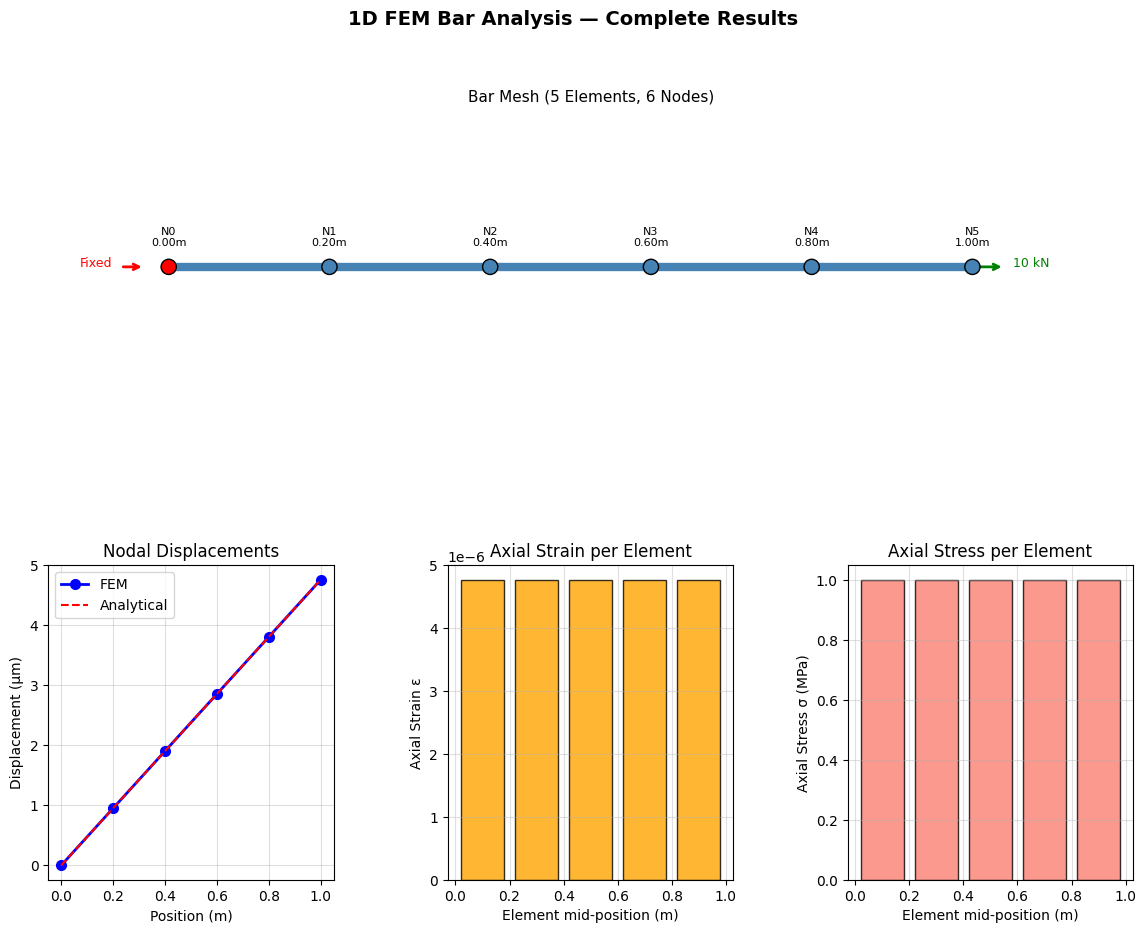

In [17]:
# VISUALIZATION
fig = plt.figure(figsize=(14, 10))
fig.suptitle("1D FEM Bar Analysis — Complete Results", fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.4)

# (a) Bar geometry and mesh
ax0 = fig.add_subplot(gs[0, :])
ax0.set_title("Bar Mesh (5 Elements, 6 Nodes)", fontsize=11)
ax0.plot([0, L], [0, 0], color='steelblue', linewidth=6)
ax0.scatter(nodes, np.zeros(n_nodes), s=120, zorder=5,
            color=['red'] + ['steelblue'] * (n_nodes - 1), edgecolors='black')
for i, x in enumerate(nodes):
    ax0.text(x, 0.02, f"N{i}\n{x:.2f}m", ha='center', fontsize=8)
# Fixed support symbol
ax0.annotate('', xy=(-0.03, 0), xytext=(-0.06, 0),
             arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax0.text(-0.07, 0, 'Fixed', ha='right', color='red', fontsize=9)
# Load arrow
ax0.annotate('', xy=(L + 0.04, 0), xytext=(L, 0),
             arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax0.text(L + 0.05, 0, '10 kN', ha='left', color='green', fontsize=9)
ax0.set_xlim(-0.15, 1.2)
ax0.set_ylim(-0.15, 0.15)
ax0.axis('off')

# (b) Displacement
ax1 = fig.add_subplot(gs[1, 0])
ax1.plot(nodes, u * 1e6, 'bo-', label='FEM', linewidth=2, markersize=7)
ax1.plot(nodes, u_analytical * 1e6, 'r--', label='Analytical', linewidth=1.5)
ax1.set_xlabel("Position (m)")
ax1.set_ylabel("Displacement (µm)")
ax1.set_title("Nodal Displacements")
ax1.legend()
ax1.grid(True, alpha=0.4)

# (c) Axial Strain
ax2 = fig.add_subplot(gs[1, 1])
x_mid = [(nodes[el[0]] + nodes[el[1]]) / 2 for el in elements]
ax2.bar(x_mid, strains, width=le * 0.8, color='orange',
        edgecolor='black', alpha=0.8)
ax2.set_xlabel("Element mid-position (m)")
ax2.set_ylabel("Axial Strain ε")
ax2.set_title("Axial Strain per Element")
ax2.grid(True, alpha=0.4)

# (d) Axial Stress
ax3 = fig.add_subplot(gs[1, 2])
ax3.bar(x_mid, [s / 1e6 for s in stresses], width=le * 0.8,
        color='salmon', edgecolor='black', alpha=0.8)
ax3.set_xlabel("Element mid-position (m)")
ax3.set_ylabel("Axial Stress σ (MPa)")
ax3.set_title("Axial Stress per Element")
ax3.grid(True, alpha=0.4)

plt.show()